In [1]:
%pip install numpy
%pip install pandas
%pip install tensorflow
%pip install matplotlib
%pip install scikit-learn
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import os, sys
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
samples = pd.read_csv(r'C:\Users\Grant\Desktop\Projects\capsim_model\sim_samples_2.csv')
samples.head()

,MKT%,Categories,Price%,Age%,Performance%,Size%,Reliability%,Acessibility%,Awarness%
0,0.213627,0,0.091837,0.20,0.000000,0.000000,-0.090909,0.61,0.65
1,0.201874,0,0.142857,0.15,0.070175,-0.027972,0.151515,0.63,0.82
2,0.190271,0,0.142857,0.20,0.035088,0.013986,0.087879,0.50,0.58
3,0.170039,0,0.142857,0.15,0.052632,-0.020979,0.060606,0.50,0.58
4,0.148616,0,0.142857,0.15,0.017544,-0.006993,-0.151515,0.46,0.58


In [4]:
# ============================================================
# 1. LOAD / PREP DATA
# ============================================================
# Assumes your dataframe is already loaded as df
# Example:
# df = pd.read_csv("your_data.csv")

target_col = "MKT%"
cat_col = "Categories"
num_cols = [
    "Price%",
    "Age%",
    "Performance%",
    "Size%",
    "Reliability%",
    "Acessibility%",
    "Awarness%"
]

# Drop missing values just in case
samples = samples[[target_col, cat_col] + num_cols].dropna().copy()

# Extract arrays
X_cat = samples[cat_col].astype(np.int32).values.reshape(-1, 1)
X_num = samples[num_cols].astype(np.float32).values
Y = samples[target_col].astype(np.float32).values.reshape(-1, 1)

# Train / validation split
X_num_train, X_num_val, X_cat_train, X_cat_val, y_train, y_val = train_test_split(
    X_num, X_cat, Y, test_size=0.1, random_state=42
)

# ============================================================
# 2. BUILD MODEL
# ============================================================
# Number of category values
num_categories = int(samples[cat_col].nunique())   # should be 5 in your case

# Inputs
num_input = keras.Input(shape=(len(num_cols),), name="numeric_features")
cat_input = keras.Input(shape=(1,), dtype=tf.int32, name="category")

# Normalize numeric features using training data only
normalizer = layers.Normalization(name="num_normalizer")
normalizer.adapt(X_num_train)

x_num = normalizer(num_input)

# Tiny category embedding
# For 5 categories, 2 dimensions is plenty
x_cat = layers.Embedding(
    input_dim=num_categories,
    output_dim=2,
    name="category_embedding"
)(cat_input)
x_cat = layers.Flatten()(x_cat)

# Combine
x = layers.Concatenate()([x_num, x_cat])

# Small regularized trunk
x = layers.Dense(
    256,
    activation="relu",
    #activation="tanh",
    kernel_regularizer=regularizers.l2(1e-3)
)(x)
x = layers.Dropout(0.50)(x)

x = layers.Dense(
    128,
    activation="relu",
    #activation="tanh",
    kernel_regularizer=regularizers.l2(1e-3)
)(x)
x = layers.Dropout(0.50)(x)

# Regression output
output = layers.Dense(1, name="mkt_percent")(x)

model = keras.Model(
    inputs=[num_input, cat_input],
    outputs=output,
    name="sparse_regression_model"
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model.summary()

# ============================================================
# 3. TRAIN
# ============================================================
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.9,
        patience=10,
        min_lr=1e-5
    )
]

history = model.fit(
    x={
        "numeric_features": X_num_train,
        "category": X_cat_train
    },
    y=y_train,
    validation_data=(
        {
            "numeric_features": X_num_val,
            "category": X_cat_val
        },
        y_val
    ),
    epochs=1000,
    batch_size=8,
    verbose=1,
    callbacks=callbacks
)

# ============================================================
# 4. EVALUATE
# ============================================================
y_pred = model.predict({
    "numeric_features": X_num_val,
    "category": X_cat_val
}, verbose=0)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\nValidation Metrics")
print(f"MAE :  {mae:.6f}")
print(f"RMSE:  {rmse:.6f}")
print(f"R^2 :  {r2:.6f}")

# ============================================================
# 5. EXAMPLE PREDICTION
# ============================================================
sample_num = np.array([[0.118644068, 0.8, 0.028846154, -0.019607843,
                        0.020408163, 0.29, 0.43]], dtype=np.float32)
sample_cat = np.array([[3]], dtype=np.int32)

pred = model.predict({
    "numeric_features": sample_num,
    "category": sample_cat
}, verbose=0)

print("\nPredicted MKT%:", float(pred[0, 0]))

Model: "sparse_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ category            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_features    │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_embedding  │ (None, 1, 2)      │         10 │ category[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_normalizer      │ (None, 7)         │         15 │ numeric_features… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2)         │          0 │ category_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9)         │          0 │ num_normalizer[0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      2,560 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mkt_percent (Dense) │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,610 (139.11 KB)

 Trainable params: 35,595 (139.04 KB)

 Non-trainable params: 15 (64.00 B)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3793 - mae: 0.3423 - rmse: 0.4951 - val_loss: 0.1577 - val_mae: 0.1500 - val_rmse: 0.1895 - learning_rate: 0.0100
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2031 - mae: 0.2052 - rmse: 0.2826 - val_loss: 0.1311 - val_mae: 0.0857 - val_rmse: 0.0999 - learning_rate: 0.0100
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1505 - mae: 0.1338 - rmse: 0.1854 - val_loss: 0.1178 - val_mae: 0.0778 - val_rmse: 0.0966 - learning_rate: 0.0100
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1149 - mae: 0.0879 - rmse: 0.1144 - val_loss: 0.0994 - val_mae: 0.0625 - val_rmse: 0.0816 - learning_rate: 0.0100
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0930 - mae: 0.0634 - rmse: 0.0832 - val_loss: 0.0845 - val_mae: 0.0632 - val_rmse: 0.0807 - learning_rate: 0.0100
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0795 - mae: 0.0638 - rmse: 0.0831 - val_loss: 0.0722 - va

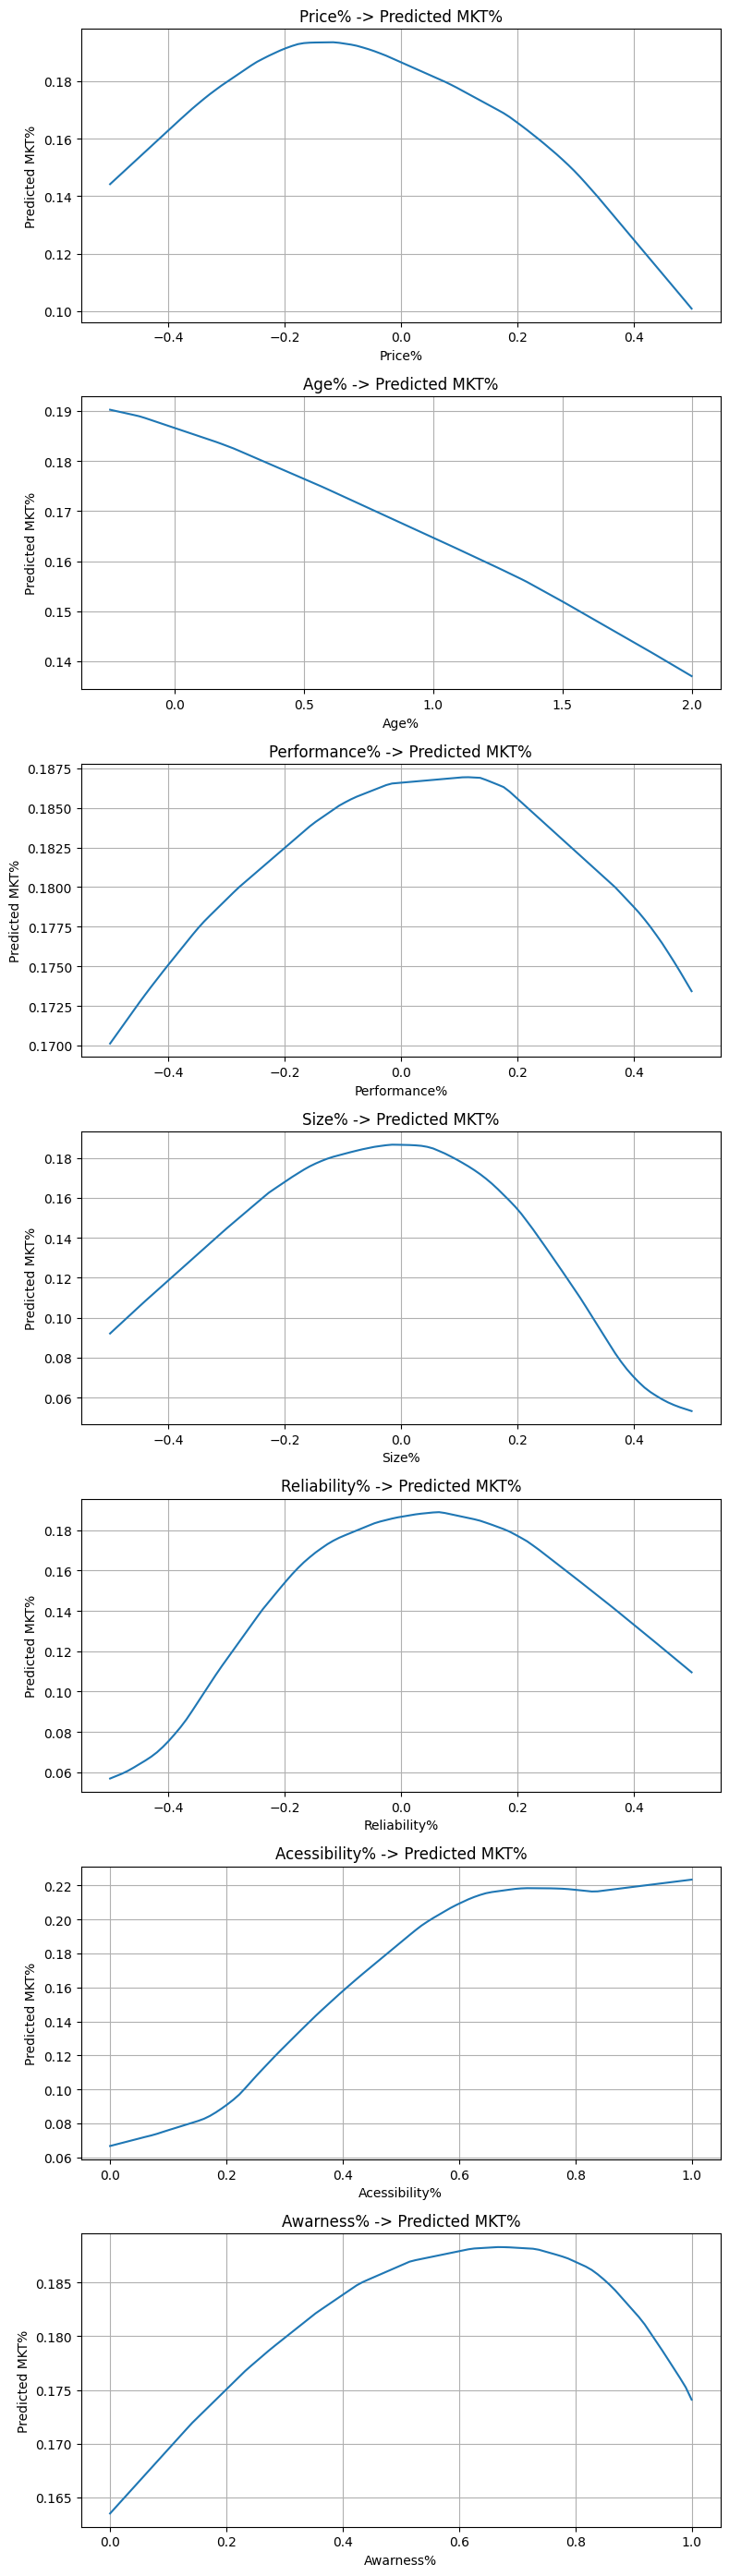

In [5]:
import numpy as np
import matplotlib.pyplot as plt

num_cols = [
    "Price%",
    "Age%",
    "Performance%",
    "Size%",
    "Reliability%",
    "Acessibility%",
    "Awarness%"
]

base_sample = {
    "Categories": 0,
    "Price%": 0.00,
    "Age%": 0.0,
    "Performance%": 0.0,
    "Size%": 0.0,
    "Reliability%": 0.0,
    "Acessibility%": 0.5,
    "Awarness%": 0.5
}

# Reasonable sweep ranges for each feature
feature_ranges = {
    "Price%": (-0.5, 0.5),
    "Age%": (-0.25, 2.0),
    "Performance%": (-0.5, 0.5),
    "Size%": (-0.5, 0.5),
    "Reliability%": (-0.5, 0.5),
    "Acessibility%": (0.0, 1.0),
    "Awarness%": (0.0, 1.0),
}

def predict_single(model, sample, num_cols):
    x_num = np.array([[sample[col] for col in num_cols]], dtype=np.float32)
    x_cat = np.array([[sample["Categories"]]], dtype=np.int32)

    return model.predict(
        {"numeric_features": x_num, "category": x_cat},
        verbose=0
    )[0, 0]

def plot_feature_sweeps(model, base_sample, num_cols, feature_ranges, num_points=100):
    n = len(num_cols)
    fig, axes = plt.subplots(n, 1, figsize=(8, 4 * n))

    if n == 1:
        axes = [axes]

    for ax, feature in zip(axes, num_cols):
        lo, hi = feature_ranges[feature]
        sweep_vals = np.linspace(lo, hi, num_points)

        preds = []
        for val in sweep_vals:
            sample = base_sample.copy()
            sample[feature] = float(val)
            preds.append(predict_single(model, sample, num_cols))

        ax.plot(sweep_vals, preds)
        ax.set_title(f"{feature} -> Predicted MKT%")
        ax.set_xlabel(feature)
        ax.set_ylabel("Predicted MKT%")
        ax.grid(True)

    plt.tight_layout()



    
    plt.show()

plot_feature_sweeps(model, base_sample, num_cols, feature_ranges)

In [5]:
model.save("models/m-v1.keras")